# MWE: how image reconstruction degrades with noise and coverage

The other MWEs show reconstructions that work. This one asks where they stop working. A synthetic scene, a star with an inclined ring and a compact blob, is observed with VLTI-like coverage at three levels of uv coverage and five levels of noise:
- **coverage:** four UTs at five hour angles; four UTs at two hour angles; three UTs at five hour angles;
- **noise:** 0.5 to 8 times the default errors of `drpangloss.coverage.vlti_oidata`, which are 0.03 in V² and 1° in closure phase.

Every case is reconstructed in the same way:
1. `starting_image`, with a hole of half a beam under the star and the image's flux free;
2. a maximum-entropy L-curve;
3. the weight chosen by the discrepancy principle, or by the L-curve's corner when χ² per point never reaches one;
4. `diagnose`.

You should come away knowing roughly how much noise and how many baselines a reconstruction like this needs, and which of `diagnose`'s warnings appear as it fails.

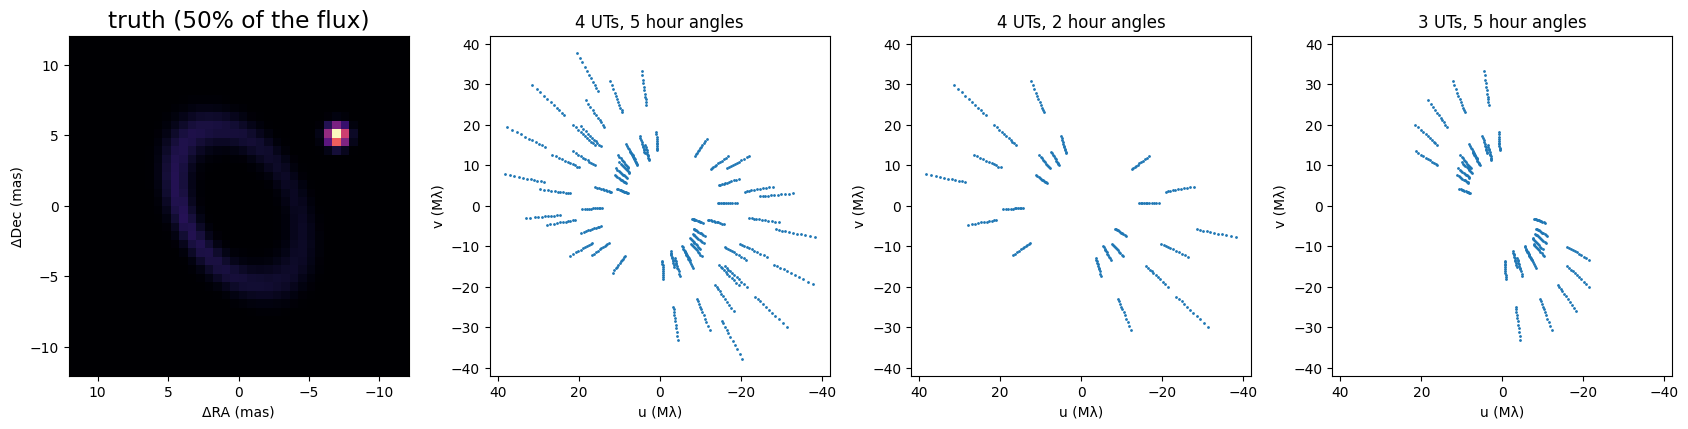

In [1]:
import sys
from pathlib import Path

root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src").exists())
sys.path.insert(0, str(root / "src"))

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpyro.distributions as dist
from tqdm.auto import tqdm

from drpangloss.coverage import VLTI_UTS, vlti_oidata
from drpangloss.imaging import MaxEntropy, beam, diagnose, field_of_view, image_priors, l_curve, starting_image
from drpangloss.models import Image, PointSource, System
from drpangloss.plotting import plot_model
from drpangloss.scenes import gaussian_blob, ring

coverages = {
    "4 UTs, 5 hour angles": dict(),
    "4 UTs, 2 hour angles": dict(hour_angles_h=(-1.5, 1.5)),
    "3 UTs, 5 hour angles": dict(stations=VLTI_UTS[:3]),
}
noise_scales = [0.5, 1.0, 2.0, 4.0, 8.0]

fov, npix = field_of_view(vlti_oidata()), 40
scale = fov / npix
truth_image = 0.8 * ring(npix, scale, 6.0, 1.0, inc_deg=50.0, pa_deg=30.0, asymmetry=0.4, asymmetry_pa_deg=90.0) + 0.2 * gaussian_blob(npix, scale, 0.5, dra=-7.0, ddec=5.0)
truth_image = truth_image / truth_image.sum()
truth = System(star=PointSource(), env=Image.from_brightness(truth_image, scale, flux=0.5))

fig, axes = plt.subplots(1, 4, figsize=(17, 4.2))
plot_model(truth.env, fov_mas=fov, npix=npix, ax=axes[0], title="truth (50% of the flux)")
for ax, (name, options) in zip(axes[1:], coverages.items()):
    d = vlti_oidata(**options)
    u, v = d.u / d.wavel / 1e6, d.v / d.wavel / 1e6
    ax.plot(jnp.concatenate([u, -u]).ravel(), jnp.concatenate([v, -v]).ravel(), ".", ms=2)
    ax.set(xlabel="u (Mλ)", ylabel="v (Mλ)", title=name, aspect="equal", xlim=(42, -42), ylim=(-42, 42))
plt.tight_layout()
plt.show()

## The sweep

Each coverage gets one noise realisation, with a fixed seed, which is scaled for each noise level, so that the trends along a row come from the noise level rather than from different draws. The table records the following:
- the NCC of the reconstruction against the truth;
- χ² per point at the chosen weight, and how that weight was chosen;
- the warnings `diagnose` raised, if any.

In [2]:
def ncc(a, b):
    a, b = a - a.mean(), b - b.mean()
    return float(jnp.sum(a * b) / jnp.sqrt(jnp.sum(a * a) * jnp.sum(b * b)))


cases = [(name, s) for name in coverages for s in noise_scales]
results = {}
for name, s in tqdm(cases, desc="cases"):
    seed = list(coverages).index(name)  # one noise draw per coverage, scaled
    data = vlti_oidata(sigma_v2=0.03 * s, sigma_cp_deg=1.0 * s, **coverages[name]).with_model(truth, key=jax.random.PRNGKey(seed))
    start = starting_image(data, hole_mas=0.5 * beam(data).minor_mas)
    priors = image_priors(start) | {"env.flux": dist.Uniform(0.0, 1.0)}
    curve = l_curve(start, priors, data, MaxEntropy(1.0, path="env"), jnp.logspace(0.5, 3.5, 7))
    weight = curve.discrepancy()
    rule = "discrepancy" if weight is not None else "corner"
    weight = weight or curve.corner()
    fitted = curve.results[int(jnp.argmin(jnp.abs(jnp.log(curve.weights) - jnp.log(weight))))]
    results[name, s] = dict(model=fitted.model, data=data, ncc=ncc(fitted.model.env.render(npix, fov), truth_image), chi2=fitted.info["chi2_red"], rule=rule, warnings=diagnose(fitted.model, data).warnings)

print(f"{'coverage':22s} {'noise':>5s} {'NCC':>5s} {'chi2/N':>7s}  {'weight by':11s} warnings")
for (name, s), r in results.items():
    flags = "; ".join(w.split(";")[0] for w in r["warnings"]) or "none"
    print(f"{name:22s} {s:5.1f} {r['ncc']:5.2f} {r['chi2']:7.2f}  {r['rule']:11s} {flags}")

cases:   0%|          | 0/15 [00:00<?, ?it/s]

W1001 17:48:07.353619 10932402 cpp_gen_intrinsics.cc:74] Empty bitcode string provided for eigen. Optimizations relying on this IR will be disabled.


/Users/benpope/code/drpangloss/src/drpangloss/imaging.py:665: RuntimeWarning: fit(method='lbfgs') did not converge in 20000 steps.
  result = fit(


coverage               noise   NCC  chi2/N  weight by   warnings
4 UTs, 5 hour angles     0.5  0.86    1.01  discrepancy none
4 UTs, 5 hour angles     1.0  0.86    0.98  discrepancy none
4 UTs, 5 hour angles     2.0  0.83    0.99  discrepancy env has 6% of its flux in the outer 2 pixels
4 UTs, 5 hour angles     4.0  0.77    1.00  discrepancy env has 10% of its flux in the outer 2 pixels
4 UTs, 5 hour angles     8.0  0.64    1.01  discrepancy env has 12% of its flux in the outer 2 pixels
4 UTs, 2 hour angles     0.5  0.67    0.99  discrepancy env has 6% of its flux in the outer 2 pixels
4 UTs, 2 hour angles     1.0  0.60    1.02  discrepancy env has 10% of its flux in the outer 2 pixels
4 UTs, 2 hour angles     2.0  0.51    1.03  discrepancy env has 14% of its flux in the outer 2 pixels
4 UTs, 2 hour angles     4.0  0.46    0.96  discrepancy env has 14% of its flux in the outer 2 pixels
4 UTs, 2 hour angles     8.0  0.39    1.00  discrepancy env has 16% of its flux in the outer 2 pixels

## Fidelity against noise

The NCC of each reconstruction against the truth, for each coverage. An NCC of 1 is perfect. As a rough guide from the other MWEs, the structure is recognisable above about 0.8.

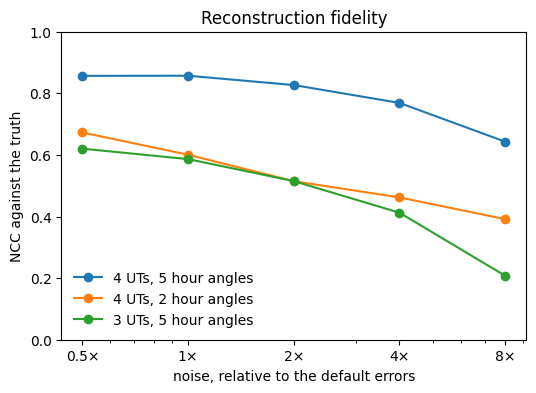

In [3]:
fig, ax = plt.subplots(figsize=(6, 4))
for name in coverages:
    ax.plot(noise_scales, [results[name, s]["ncc"] for s in noise_scales], "o-", label=name)
ax.set(xscale="log", xlabel="noise, relative to the default errors", ylabel="NCC against the truth", title="Reconstruction fidelity", ylim=(0, 1))
ax.set_xticks(noise_scales, [f"{s:g}×" for s in noise_scales])
ax.legend(frameon=False)
plt.show()

## The reconstructions

Every reconstruction, one row per coverage and one column per noise level, with the data's beam shaded. They are drawn in the field the truth was made in. `starting_image` sizes each reconstruction's own field from its data, so a reconstruction with a smaller field shows a dark border. With three UTs the beam is so elongated that it overlaps the source even in the lower-left corner.

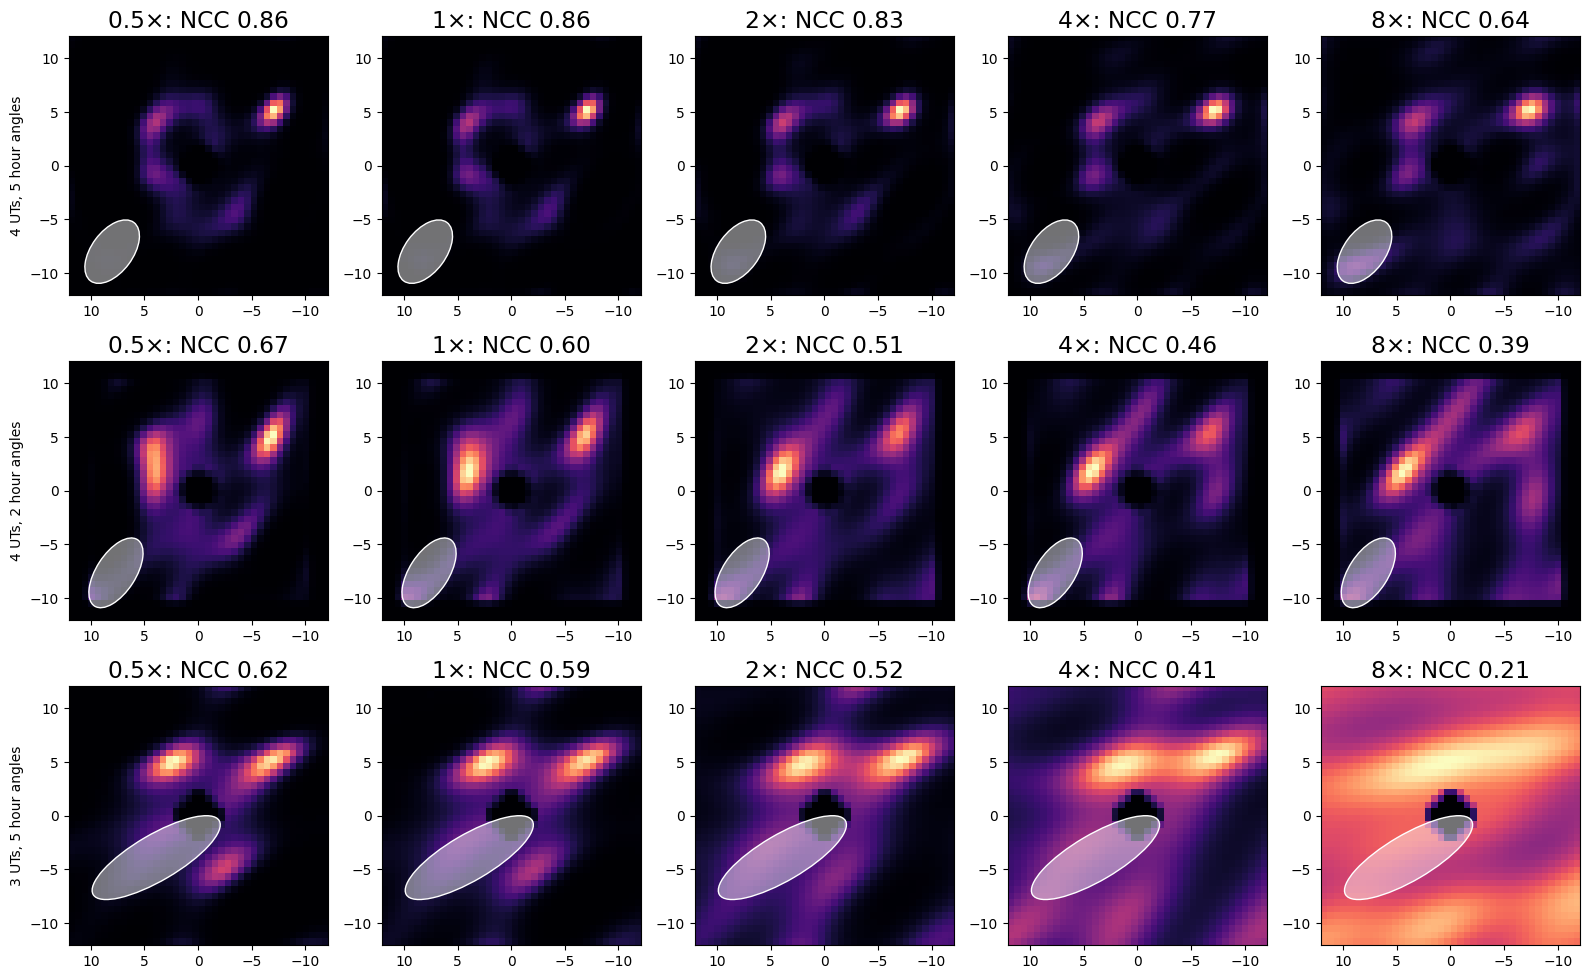

In [4]:
fig, axes = plt.subplots(len(coverages), len(noise_scales), figsize=(3.2 * len(noise_scales), 3.3 * len(coverages)))
for row, name in zip(axes, coverages):
    for ax, s in zip(row, noise_scales):
        r = results[name, s]
        plot_model(r["model"].env, fov_mas=fov, npix=npix, ax=ax, title=f"{s:g}×: NCC {r['ncc']:.2f}", beam=beam(r["data"]))
        ax.set(xlabel="", ylabel="")
    row[0].set_ylabel(name)
plt.tight_layout()
plt.show()

## Summary

The table and the figures show where the reconstruction degrades. Three effects matter:
- **Noise.** With full coverage, fidelity falls slowly, from NCC 0.86 at 0.5× and 1× the default errors to 0.77 at 4× and 0.64 at 8×. The discrepancy principle picks larger weights, and the image gets smoother, with a smooth floor across the field at high noise.
- **Coverage.** Thinner coverage costs more than noise does. Two hour angles, or a missing telescope, give NCC of only about 0.6 even at low noise, because the beam is elongated and the uv plane has gaps; and with three telescopes there is only one closure phase per hour angle. With three UTs and 8× noise the image is lost (NCC 0.21).
- **Diagnostics.** χ² per point reached one in every case, so a good χ² says nothing about fidelity. `diagnose`'s edge-flux warning flags images that spread flux to the edge of the field, which is how high noise shows itself. It does not catch failures that come from coverage alone: three UTs at 0.5× has NCC 0.62 and no warning.

Simulating the same scene with the real coverage and errors of an observation is the quickest way to know which regime it is in.